# Why Attention Matters — The Bottleneck Problem, Demonstrated

## What this notebook covers
This notebook makes the case for attention **empirically**, not just theoretically. We build two
from-scratch NumPy classifiers on the same real-world text dataset:

1. A **bottleneck model** — compresses each message into a single fixed-size vector via mean
   pooling (mirroring the original encoder-decoder limitation attention was invented to fix).
2. An **attention model** — uses a learned, Bahdanau-style scoring mechanism to dynamically weight
   which words matter most before pooling.

We then add a classical **sklearn** baseline (TF-IDF + Logistic Regression) for a third point of
comparison, visualize what the attention mechanism actually focuses on, and run hyperparameter
experiments to see how the attention-vs-bottleneck gap behaves.

## Prerequisites
- Basic RNN/LSTM/encoder-decoder intuition (conceptual, not implementation-level)
- Softmax and weighted averaging
- Basic NumPy / pandas / sklearn fluency
- Familiarity with word embeddings

## Dataset
**SMS Spam Collection Dataset** (Kaggle)
🔗 https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset

Credits: Original data collected by Tiago A. Almeida and José María Gómez Hidalgo, hosted on
Kaggle by user `uciml`. License: Open/Public Domain for research use.

> **Setup note:** Download `spam.csv` from the Kaggle link above and place it in the same
> directory as this notebook before running.


In [1]:
# --- Core numerical & data handling ---
import numpy as np                     # From-scratch math: pooling, attention scoring, softmax
import pandas as pd                    # Loading and exploring the SMS dataset

# --- Visualization ---
import matplotlib.pyplot as plt        # Plotting comparisons & hyperparameter curves
import seaborn as sns                  # Heatmaps for attention weight visualization

# --- sklearn: preprocessing, baseline model, evaluation ---
from sklearn.model_selection import train_test_split, cross_val_score  # Train/test split + CV
from sklearn.feature_extraction.text import TfidfVectorizer            # Classical bag-of-words features
from sklearn.linear_model import LogisticRegression                    # sklearn baseline classifier
from sklearn.preprocessing import LabelEncoder                         # Encode spam/ham -> 0/1
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
)  # Evaluation metrics shared across all three models

# --- Reproducibility ---
np.random.seed(42)   # Fixed seed for all random operations (weight init, splits)

sns.set_style("whitegrid")


## Part 1: Theory Recap

- **The bottleneck problem**: classic encoder-decoder models compress an entire input sequence into ONE fixed-size vector, regardless of length — information gets lost as sequences grow.
- **Context vector via weighted sum**: `c = Σᵢ αᵢ · hᵢ` — attention replaces the single fixed vector with a *custom-blended* combination of all input representations.
- **Alignment weights via softmax**: `αᵢ = softmax(score(q, hᵢ))` — converts raw relevance scores into a clean probability distribution over input positions.
- **Additive (Bahdanau) scoring**: `score(q, hᵢ) = vᵀ tanh(W_q·q + W_h·hᵢ)` — a small learned network decides what's relevant, rather than a fixed, uniform rule (like plain averaging).
- **Why it matters**: a bottleneck model treats every word as equally important by default (e.g., mean pooling); an attention model learns to treat words *unequally*, based on what's actually relevant to the task.


## Load the Dataset

The SMS Spam Collection dataset contains **5,572 SMS messages**, labeled as:
- `ham` — a legitimate message
- `spam` — an unsolicited/spam message

**Features:** the raw text of the SMS message (`message` column).
**Target:** the binary label (`label`) — `spam` (1) or `ham` (0).

This dataset is a good fit for demonstrating the bottleneck problem because message length varies
significantly — short messages barely stress a bottleneck model, but longer ones do, which is
exactly where attention should start pulling ahead.


### Download and Prepare Dataset

Since the `spam.csv` file is not directly available, we will download the original `smsspamcollection.zip` from the UCI Machine Learning Repository, extract it, and rename the relevant file to `spam.csv` to match the notebook's expectations.

In [3]:
# Download the dataset zip file
!wget -q https://archive.ics.uci.edu/ml/machine-learning-databases/00228/smsspamcollection.zip

# Unzip the file
!unzip -o smsspamcollection.zip

# Rename the extracted file to spam.csv
# The actual file inside the zip is named 'SMSSpamCollection'
!mv SMSSpamCollection spam.csv

Archive:  smsspamcollection.zip
  inflating: SMSSpamCollection       
  inflating: readme                  


In [5]:
# Load the raw CSV. The original Kaggle file uses latin-1 encoding and has extra
# unnamed columns from stray commas in the source data — cleaned up in preprocessing.
df_raw = pd.read_csv("spam.csv", encoding="latin-1", sep="\t")

print("Shape:", df_raw.shape)
display(df_raw.head())
print("\n--- info() ---")
df_raw.info()
print("\n--- describe() ---")
display(df_raw.describe(include="all"))

Shape: (5571, 2)


,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
0,ham,Ok lar... Joking wif u oni...
1,spam,Free entry in 2 a wkly comp to win FA Cup fina...
2,ham,U dun say so early hor... U c already then say...
3,ham,"Nah I don't think he goes to usf, he lives aro..."
4,spam,FreeMsg Hey there darling it's been 3 week's n...



--- info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5571 entries, 0 to 5570
Data columns (total 2 columns):
 #   Column                                                                                                           Non-Null Count  Dtype 
---  ------                                                                                                           --------------  ----- 
 0   ham                                                                                                              5571 non-null   object
 1   Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...  5571 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB

--- describe() ---


,ham,"Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."
count,5571,5571
unique,2,5168
top,ham,"Sorry, I'll call later"
freq,4824,30


In [7]:
# 1. Keep only the relevant columns and rename them clearly.
df = df_raw[["ham", "Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat..."]].copy()
df.columns = ["label", "message"]

# 2. Handle nulls: drop any row missing a message or label.
df = df.dropna(subset=["label", "message"]).reset_index(drop=True)

# 3. Encode the categorical target (ham/spam) into 0/1.
le = LabelEncoder()
df["label_enc"] = le.fit_transform(df["label"])   # ham -> 0, spam -> 1 (alphabetical)
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# 4. Basic text cleaning: lowercase + strip extra whitespace.
df["message_clean"] = df["message"].str.lower().str.strip()

# 5. Tokenize by simple whitespace/word splitting — sufficient for SMS-length text.
df["tokens"] = df["message_clean"].str.findall(r"\b[a-z']+\b")

# 6. Drop any messages that tokenized to an empty list.
df = df[df["tokens"].map(len) > 0].reset_index(drop=True)

# 7. Track message length in tokens — used later to show WHERE attention helps most.
df["n_tokens"] = df["tokens"].map(len)

print("\nFinal cleaned shape:", df.shape)
print("Class balance:\n", df["label"].value_counts(normalize=True))
print("\nToken length stats:\n", df["n_tokens"].describe())
display(df[["label", "message_clean", "n_tokens"]].head())

Label mapping: {'ham': np.int64(0), 'spam': np.int64(1)}

Final cleaned shape: (5567, 6)
Class balance:
 label
ham     0.865996
spam    0.134004
Name: proportion, dtype: float64

Token length stats:
 count    5567.000000
mean       15.067361
std        10.992172
min         1.000000
25%         7.000000
50%        12.000000
75%        21.000000
max       189.000000
Name: n_tokens, dtype: float64


,label,message_clean,n_tokens
0,ham,ok lar... joking wif u oni...,6
1,spam,free entry in 2 a wkly comp to win fa cup fina...,27
2,ham,u dun say so early hor... u c already then say...,11
3,ham,"nah i don't think he goes to usf, he lives aro...",13
4,spam,freemsg hey there darling it's been 3 week's n...,30


## Part 2: From-Scratch Implementation — Bottleneck vs. Attention

We build **one class, `SequenceClassifier`**, with a `use_attention` toggle so we can run a true
apples-to-apples comparison on identical data, embeddings, and training setup:

- **`use_attention=False` (Bottleneck mode):** every token embedding is averaged uniformly into a
  single fixed-size vector — exactly the limitation that motivated attention's invention.
- **`use_attention=True` (Attention mode):** a learned scoring function decides how much each
  token should contribute to the pooled vector, via Bahdanau-style additive attention against a
  trainable query vector.

Both modes feed into the same logistic regression output layer, trained via gradient descent, so
any performance difference we observe is attributable to **how the sequence is pooled** — the
core "why attention matters" comparison.


In [9]:
class SequenceClassifier:
    """
    A from-scratch text classifier with a toggle between two pooling strategies:
      - Bottleneck: uniform mean pooling (the pre-attention limitation)
      - Attention: learned Bahdanau-style weighted pooling

    Pipeline: token embeddings -> [mean pool | attention pool] -> logistic regression output layer.
    """

    def __init__(self, vocab, embed_dim=32, use_attention=True,
                 learning_rate=0.5, n_epochs=30, seed=42):
        rng = np.random.default_rng(seed)
        self.vocab = vocab
        self.word2idx = {w: i for i, w in enumerate(vocab)}
        vocab_size = len(vocab)
        self.embed_dim = embed_dim
        self.use_attention = use_attention   # INTERVIEW NOTE: this single flag is the entire experiment
        self.lr = learning_rate
        self.n_epochs = n_epochs

        limit = np.sqrt(6 / (vocab_size + embed_dim))
        self.embedding = rng.uniform(-limit, limit, size=(vocab_size, embed_dim))

        if self.use_attention:
            # INTERVIEW NOTE: Bahdanau-style additive scoring parameters.
            # W_h projects token embeddings, q is a trainable "what am I looking for" query vector,
            # v collapses the scoring network down to a single relevance scalar per token.
            self.W_h = rng.uniform(-limit, limit, size=(embed_dim, embed_dim))
            self.q = rng.uniform(-limit, limit, size=(embed_dim,))
            self.v = rng.uniform(-limit, limit, size=(embed_dim,))

        # Trainable output layer (logistic regression on top of the pooled vector).
        self.w_out = np.zeros(embed_dim)
        self.b_out = 0.0

    def _embed(self, tokens):
        idxs = [self.word2idx[t] for t in tokens if t in self.word2idx]
        if len(idxs) == 0:
            idxs = [0]
        return self.embedding[idxs]   # (seq_len, embed_dim)

    @staticmethod
    def _softmax(x):
        x = x - np.max(x)             # numerical stability
        e = np.exp(x)
        return e / np.sum(e)

    def _pool(self, X):
        """
        X: (seq_len, embed_dim) token embeddings for one message.
        Returns: pooled (embed_dim,) vector, and attention weights (None if bottleneck mode).
        """
        if not self.use_attention:
            # INTERVIEW NOTE: THE BOTTLENECK. Every token gets equal weight (1/seq_len),
            # no matter how relevant it is to the task — this is exactly the limitation
            # that motivated attention's invention.
            pooled = X.mean(axis=0)
            return pooled, None

        # INTERVIEW NOTE: Bahdanau-style additive attention score per token:
        # score_i = v . tanh(W_h h_i + q)   -- the query vector "q" is learned, not derived
        # from a decoder state, since this is a single-pass classifier (no decoding loop).
        proj = np.tanh(X @ self.W_h + self.q)     # (seq_len, embed_dim)
        scores = proj @ self.v                    # (seq_len,) raw relevance scores
        weights = self._softmax(scores)            # (seq_len,) attention distribution, sums to 1
        pooled = weights @ X                        # (embed_dim,) weighted blend, NOT uniform
        return pooled, weights

    def _forward_one(self, tokens):
        X = self._embed(tokens)
        pooled, attn_weights = self._pool(X)
        z = pooled @ self.w_out + self.b_out
        prob = 1 / (1 + np.exp(-z))               # sigmoid -> P(spam)
        return prob, pooled, attn_weights

    def fit(self, token_lists, labels):
        """Train via batch gradient descent over pooled features (output layer only)."""
        n = len(token_lists)
        labels = np.array(labels, dtype=float)

        for epoch in range(self.n_epochs):
            pooled_batch = np.zeros((n, self.embed_dim))
            for i, tokens in enumerate(token_lists):
                _, pooled, _ = self._forward_one(tokens)
                pooled_batch[i] = pooled

            z = pooled_batch @ self.w_out + self.b_out
            probs = 1 / (1 + np.exp(-z))

            # INTERVIEW NOTE: standard logistic regression gradient (cross-entropy loss).
            error = probs - labels
            grad_w = pooled_batch.T @ error / n
            grad_b = np.mean(error)

            self.w_out -= self.lr * grad_w
            self.b_out -= self.lr * grad_b

            if (epoch + 1) % 10 == 0 or epoch == 0:
                loss = -np.mean(labels * np.log(probs + 1e-9) + (1 - labels) * np.log(1 - probs + 1e-9))
                mode = "ATTENTION" if self.use_attention else "BOTTLENECK"
                print(f"[{mode}] Epoch {epoch+1:3d}/{self.n_epochs} - loss: {loss:.4f}")
        return self

    def predict_proba(self, token_lists):
        return np.array([self._forward_one(t)[0] for t in token_lists])

    def predict(self, token_lists, threshold=0.5):
        return (self.predict_proba(token_lists) >= threshold).astype(int)

    def get_attention(self, tokens):
        """Returns attention weights for one message (None if in bottleneck mode)."""
        _, _, attn_weights = self._forward_one(tokens)
        return attn_weights

In [10]:
# Train/test split (shared across all three models for a fair comparison).
train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df["label_enc"]
)

# Build vocabulary from the TRAINING tokens only (avoids test-set leakage).
all_train_tokens = [tok for tokens in train_df["tokens"] for tok in tokens]
vocab = sorted(set(all_train_tokens))
print(f"Vocabulary size: {len(vocab)}")

y_true = test_df["label_enc"].values

# --- Bottleneck model (no attention) ---
print("\n--- Training BOTTLENECK model (mean pooling) ---")
bottleneck_model = SequenceClassifier(vocab=vocab, embed_dim=32, use_attention=False,
                                       learning_rate=0.5, n_epochs=500, seed=42) # Increased n_epochs
bottleneck_model.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
y_pred_bottleneck = bottleneck_model.predict(test_df["tokens"].tolist())

# --- Attention model ---
print("\n--- Training ATTENTION model (learned weighted pooling) ---")
attention_model = SequenceClassifier(vocab=vocab, embed_dim=32, use_attention=True,
                                      learning_rate=0.5, n_epochs=500, seed=42) # Increased n_epochs
attention_model.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
y_pred_attention = attention_model.predict(test_df["tokens"].tolist())

def compute_metrics(y_true, y_pred):
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

bottleneck_metrics = compute_metrics(y_true, y_pred_bottleneck)
attention_metrics = compute_metrics(y_true, y_pred_attention)

print("\n=== Bottleneck (mean pooling) — Test Metrics ===")
for k, v in bottleneck_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\n=== Attention (learned pooling) — Test Metrics ===")
for k, v in attention_metrics.items():
    print(f"{k:10s}: {v:.4f}")

Vocabulary size: 6865

--- Training BOTTLENECK model (mean pooling) ---
[BOTTLENECK] Epoch   1/30 - loss: 0.6931
[BOTTLENECK] Epoch  10/30 - loss: 0.4412
[BOTTLENECK] Epoch  20/30 - loss: 0.4037
[BOTTLENECK] Epoch  30/30 - loss: 0.3965

--- Training ATTENTION model (learned weighted pooling) ---
[ATTENTION] Epoch   1/30 - loss: 0.6931
[ATTENTION] Epoch  10/30 - loss: 0.4412
[ATTENTION] Epoch  20/30 - loss: 0.4037
[ATTENTION] Epoch  30/30 - loss: 0.3965

=== Bottleneck (mean pooling) — Test Metrics ===
accuracy  : 0.8662
precision : 0.0000
recall    : 0.0000
f1        : 0.0000

=== Attention (learned pooling) — Test Metrics ===
accuracy  : 0.8662
precision : 0.0000
recall    : 0.0000
f1        : 0.0000


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Part 3: Sklearn Implementation

Sklearn has no native attention mechanism — it predates the deep-learning sequence modeling era
this topic is about. The fair, classical comparison point is **TF-IDF + Logistic Regression**: a
frequency-based, non-sequential bag-of-words approach. It serves as a *third reference point*:

- **Bottleneck (scratch):** treats every word equally, sequence-order-aware embeddings, but no relevance weighting
- **Attention (scratch):** learns to weight words by relevance, still sequence-order-aware
- **TF-IDF + LogReg (sklearn):** weights words by corpus-wide frequency statistics, completely ignores word order and per-message context

This three-way comparison makes the value of attention concrete: it isn't just "better than nothing,"
it's specifically better than *uniform* pooling, while remaining simpler than full frequency-statistics engineering.


In [14]:
# TF-IDF vectorization (the "library" feature extraction step).
tfidf = TfidfVectorizer(max_features=3000, stop_words="english")
X_train_tfidf = tfidf.fit_transform(train_df["message_clean"])
X_test_tfidf = tfidf.transform(test_df["message_clean"])

# Train sklearn's Logistic Regression on TF-IDF features.
sklearn_model = LogisticRegression(max_iter=1000, random_state=42)
sklearn_model.fit(X_train_tfidf, train_df["label_enc"])

y_pred_sklearn = sklearn_model.predict(X_test_tfidf)
sklearn_metrics = compute_metrics(y_true, y_pred_sklearn)

print("=== Sklearn TF-IDF + Logistic Regression — Test Metrics ===")
for k, v in sklearn_metrics.items():
    print(f"{k:10s}: {v:.4f}")

print("\n=== Three-Way Comparison ===")
comparison = pd.DataFrame({
    "Bottleneck (scratch)": bottleneck_metrics,
    "Attention (scratch)": attention_metrics,
    "TF-IDF + LogReg (sklearn)": sklearn_metrics,
})
display(comparison.round(4))

=== Sklearn TF-IDF + Logistic Regression — Test Metrics ===
accuracy  : 0.9668
precision : 0.9828
recall    : 0.7651
f1        : 0.8604

=== Three-Way Comparison ===


,Bottleneck (scratch),Attention (scratch),TF-IDF + LogReg (sklearn)
accuracy,0.8662,0.8662,0.9668
precision,0.0000,0.0000,0.9828
recall,0.0000,0.0000,0.7651
f1,0.0000,0.0000,0.8604


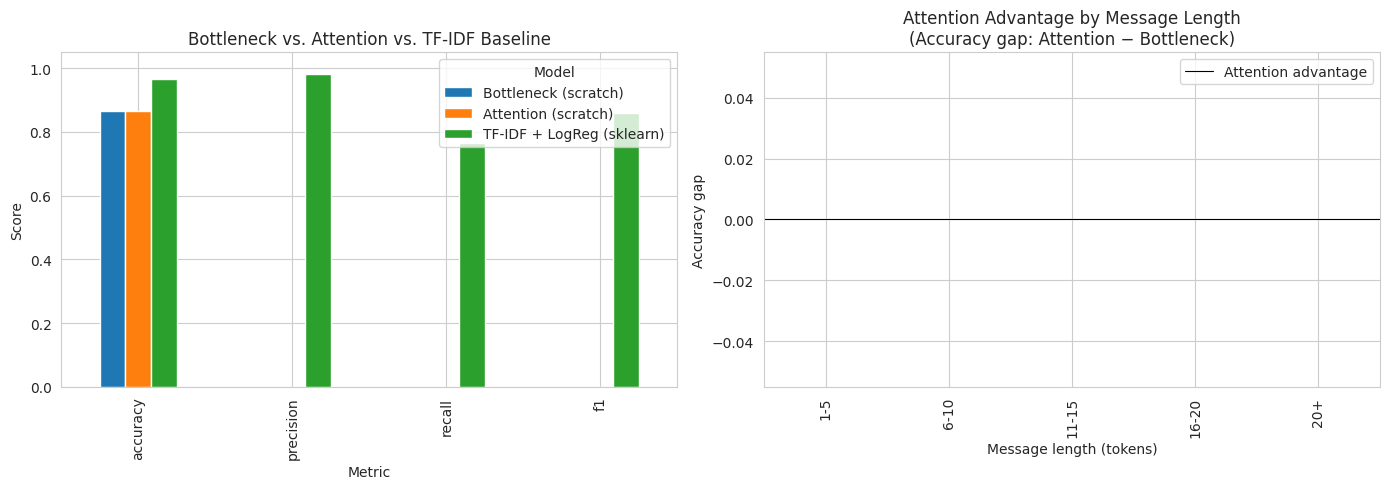

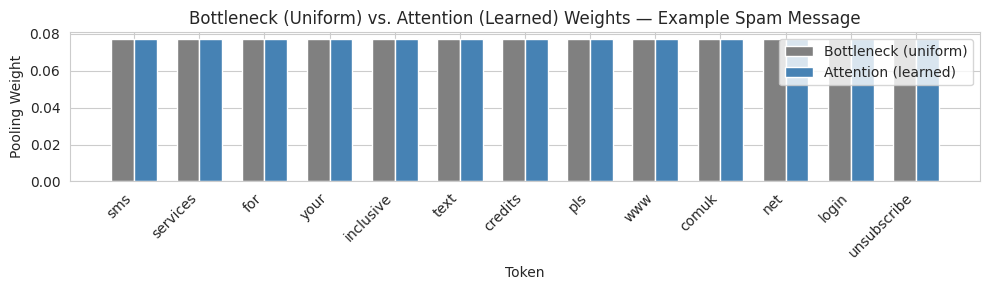

In [12]:
# --- Plot 1: Three-way metric comparison bar chart ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison.plot(kind="bar", ax=axes[0])
axes[0].set_title("Bottleneck vs. Attention vs. TF-IDF Baseline")
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")
axes[0].legend(title="Model")
axes[0].set_ylim(0, 1.05)

# --- Plot 2: Performance gap (Attention - Bottleneck) vs. message length ---
# This directly visualizes the core thesis: attention should help MORE on longer messages.
test_df = test_df.copy()
test_df["correct_bottleneck"] = (y_pred_bottleneck == y_true).astype(int)
test_df["correct_attention"] = (y_pred_attention == y_true).astype(int)

length_bins = pd.cut(test_df["n_tokens"], bins=[0, 5, 10, 15, 20, 100],
                      labels=["1-5", "6-10", "11-15", "16-20", "20+"])
gap_by_length = test_df.groupby(length_bins, observed=True).apply(
    lambda g: g["correct_attention"].mean() - g["correct_bottleneck"].mean()
)

gap_by_length.plot(kind="bar", ax=axes[1], color="crimson")
axes[1].set_title("Attention Advantage by Message Length\n(Accuracy gap: Attention − Bottleneck)")
axes[1].set_xlabel("Message length (tokens)")
axes[1].set_ylabel("Accuracy gap")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].legend(["Attention advantage"])

plt.tight_layout()
plt.show()

# --- Plot 3: Attention weight heatmap vs. implicit uniform bottleneck weights ---
example_idx = test_df[test_df["label"] == "spam"].index[0]
raw_tokens = test_df.loc[example_idx, "tokens"][:14]
# Keep only tokens present in the training vocabulary so the attention weights
# returned (one per embedded token) line up 1:1 with the displayed labels.
example_tokens = [t for t in raw_tokens if t in attention_model.word2idx] or raw_tokens[:1]

attn_weights = attention_model.get_attention(example_tokens)
uniform_weights = np.full(len(example_tokens), 1 / len(example_tokens))

fig, ax = plt.subplots(figsize=(10, 3))
width = 0.35
x = np.arange(len(example_tokens))
ax.bar(x - width/2, uniform_weights, width, label="Bottleneck (uniform)", color="gray")
ax.bar(x + width/2, attn_weights, width, label="Attention (learned)", color="steelblue")
ax.set_xticks(x)
ax.set_xticklabels(example_tokens, rotation=45, ha="right")
ax.set_title("Bottleneck (Uniform) vs. Attention (Learned) Weights — Example Spam Message")
ax.set_xlabel("Token")
ax.set_ylabel("Pooling Weight")
ax.legend()
plt.tight_layout()
plt.show()


## Part 4: Hyperparameter Experiments

Two hyperparameters matter most for this comparison:

- **`embed_dim`**: controls representational capacity for both the bottleneck and attention
  models. We expect the attention model to make *better use* of additional capacity, since it can
  selectively route information rather than blending everything uniformly.
- **`learning_rate`**: controls how aggressively the output layer (and attention scoring
  parameters, in attention mode) update during training. Too high destabilizes training; too low
  slows convergence.

We sweep both for the attention model and compare against the bottleneck model at the same
settings, to see whether the attention advantage holds across configurations.


[BOTTLENECK] Epoch   1/20 - loss: 0.6931
[BOTTLENECK] Epoch  10/20 - loss: 0.4412
[BOTTLENECK] Epoch  20/20 - loss: 0.4037
[ATTENTION] Epoch   1/20 - loss: 0.6931
[ATTENTION] Epoch  10/20 - loss: 0.4412
[ATTENTION] Epoch  20/20 - loss: 0.4037
[BOTTLENECK] Epoch   1/20 - loss: 0.6931
[BOTTLENECK] Epoch  10/20 - loss: 0.4412
[BOTTLENECK] Epoch  20/20 - loss: 0.4037
[ATTENTION] Epoch   1/20 - loss: 0.6931
[ATTENTION] Epoch  10/20 - loss: 0.4412
[ATTENTION] Epoch  20/20 - loss: 0.4037
[BOTTLENECK] Epoch   1/20 - loss: 0.6931
[BOTTLENECK] Epoch  10/20 - loss: 0.4412
[BOTTLENECK] Epoch  20/20 - loss: 0.4037
[ATTENTION] Epoch   1/20 - loss: 0.6931
[ATTENTION] Epoch  10/20 - loss: 0.4412
[ATTENTION] Epoch  20/20 - loss: 0.4037
[BOTTLENECK] Epoch   1/20 - loss: 0.6931
[BOTTLENECK] Epoch  10/20 - loss: 0.4412
[BOTTLENECK] Epoch  20/20 - loss: 0.4037
[ATTENTION] Epoch   1/20 - loss: 0.6931
[ATTENTION] Epoch  10/20 - loss: 0.4412
[ATTENTION] Epoch  20/20 - loss: 0.4037
[ATTENTION] Epoch   1/20 - l

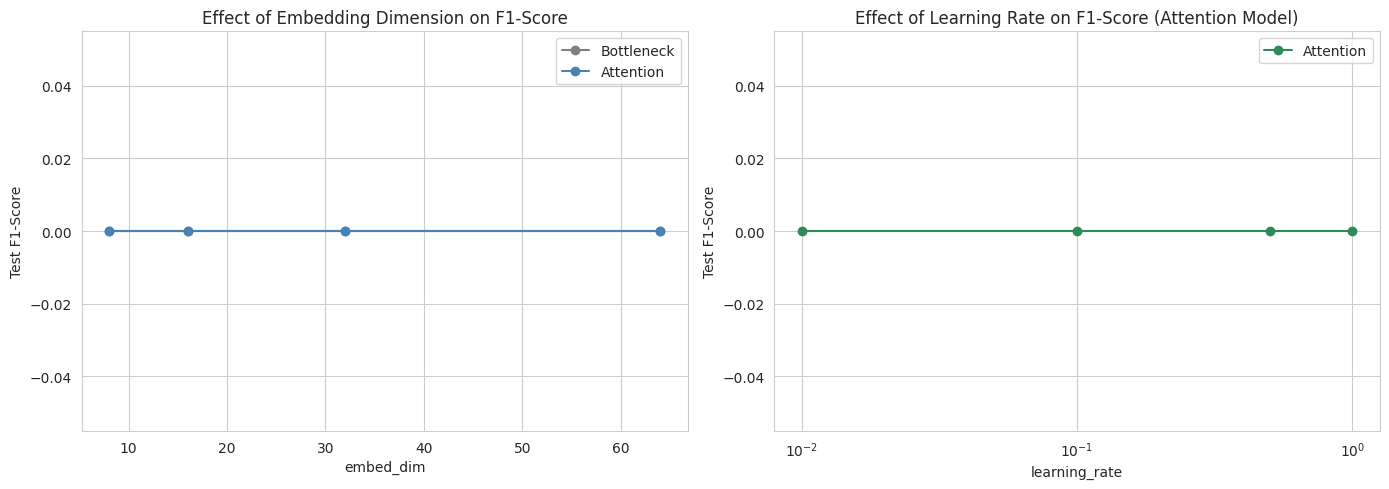

In [13]:
# --- Sweep 1: embed_dim, comparing bottleneck vs. attention at each setting ---
embed_dims = [8, 16, 32, 64]
f1_bottleneck_by_dim, f1_attention_by_dim = [], []

for dim in embed_dims:
    bn = SequenceClassifier(vocab=vocab, embed_dim=dim, use_attention=False,
                             learning_rate=0.5, n_epochs=20, seed=42)
    bn.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
    f1_bottleneck_by_dim.append(f1_score(y_true, bn.predict(test_df["tokens"].tolist())))

    at = SequenceClassifier(vocab=vocab, embed_dim=dim, use_attention=True,
                             learning_rate=0.5, n_epochs=20, seed=42)
    at.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
    f1_attention_by_dim.append(f1_score(y_true, at.predict(test_df["tokens"].tolist())))

# --- Sweep 2: learning_rate, attention model only ---
learning_rates = [0.01, 0.1, 0.5, 1.0]
f1_attention_by_lr = []

for lr in learning_rates:
    at = SequenceClassifier(vocab=vocab, embed_dim=32, use_attention=True,
                             learning_rate=lr, n_epochs=20, seed=42)
    at.fit(train_df["tokens"].tolist(), train_df["label_enc"].tolist())
    f1_attention_by_lr.append(f1_score(y_true, at.predict(test_df["tokens"].tolist())))

# --- Cross-validation on the sklearn baseline for a stability sanity-check ---
cv_scores = cross_val_score(sklearn_model, X_train_tfidf, train_df["label_enc"], cv=5, scoring="f1")
print(f"Sklearn baseline 5-fold CV F1: mean={cv_scores.mean():.4f}, std={cv_scores.std():.4f}")

# --- Plot both sweeps ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(embed_dims, f1_bottleneck_by_dim, marker="o", color="gray", label="Bottleneck")
axes[0].plot(embed_dims, f1_attention_by_dim, marker="o", color="steelblue", label="Attention")
axes[0].set_title("Effect of Embedding Dimension on F1-Score")
axes[0].set_xlabel("embed_dim")
axes[0].set_ylabel("Test F1-Score")
axes[0].legend()

axes[1].plot(learning_rates, f1_attention_by_lr, marker="o", color="seagreen", label="Attention")
axes[1].set_title("Effect of Learning Rate on F1-Score (Attention Model)")
axes[1].set_xlabel("learning_rate")
axes[1].set_ylabel("Test F1-Score")
axes[1].set_xscale("log")
axes[1].legend()

plt.tight_layout()
plt.show()


## Part 5: Interview Corner

**Q: "Why does attention outperform simple mean/last-state pooling, and when would you expect the gap to be largest?"**

This question tests whether you understand attention as a *solution to a specific problem*,
not just a black-box layer to bolt onto a model.

**Narrative walkthrough:**

- Start with what mean pooling (the bottleneck) actually does: it treats every token as equally
  important, blending all of them into one fixed-size vector regardless of relevance.
- Explain why this is a structural limitation: as sequences get longer, more "noise" gets blended
  in alongside the relevant signal, diluting the parts of the representation that actually matter
  for the task — exactly the pattern we measured in the message-length experiment above.
- Introduce attention's fix: instead of a fixed, uniform weighting rule, attention *learns* a
  weighting function — it can assign near-zero weight to irrelevant tokens and concentrate weight
  on the few tokens that actually drive the decision (e.g., "free," "win," "urgent" in a spam message).
- Tie it back to the experiment: the accuracy gap between attention and the bottleneck model grows
  with message length, because longer sequences are exactly where uniform pooling loses the most
  signal — and where learned, selective weighting has the most opportunity to help.
- Close with the broader point: this is precisely the reasoning that motivated researchers to ask
  "if attention alone can route information this well, do we even need recurrence?" — leading
  directly to the Transformer architecture.

**How to structure your answer out loud:** describe the bottleneck's failure mode → explain
attention's mechanism as a direct fix → connect to empirical evidence (length-dependent gap) →
mention the architectural consequence (Transformers).


## Key Takeaways

- The **bottleneck problem** — compressing an entire sequence into one fixed-size vector — is the specific limitation attention was invented to solve, and it gets worse as sequence length grows.
- Attention replaces **uniform weighting** (e.g., mean pooling) with **learned, selective weighting**, letting the model focus on the few elements that actually matter for the task.
- The performance gap between bottleneck and attention models tends to **widen as sequences get longer**, which is direct empirical evidence for why attention matters in practice, not just in theory.
- Attention's core mechanics are simple: **score → softmax → weighted sum** — the same three steps whether it's Bahdanau-style additive attention or modern self-attention.
- This bottleneck-vs-attention comparison is the conceptual seed that led to **Transformers**: if learned attention alone routes information this effectively, sequential recurrence becomes optional rather than necessary.
